In [3]:
from google.colab import files

In [4]:
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


# **Task 1: Data Loading & Cleaning**

In [5]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

**Step 1.1: Check Dataset Information**

In [7]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


**Step 1.2: Check Missing Values**

In [8]:
# Check missing values
missing_values = df.isnull().sum()

print(missing_values)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percent
})

missing_summary

,Missing Values,Percentage (%)
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,1454,0.268311
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,135080,24.926694
Country,0,0.000000


**Step 1.3: Handle Missing Values**

The Online Retail dataset usually has missing values only in CustomerID and a few in Description.

In [10]:
# Remove rows with missing Description
df = df.dropna(subset=['Description'])

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove duplicate records
df = df.drop_duplicates()

print("Dataset Shape after Cleaning:", df.shape)

Dataset Shape after Cleaning: (401604, 8)


**Step 1.4: Explain Your Strategy (for the report)**

Missing values were checked using the isnull() function. Records with missing Description were removed because the product could not be identified. Records with missing CustomerID were also removed since customer-level analysis requires a valid customer identifier. Finally, duplicate records were removed to avoid counting the same transaction more than once.

**Step 1.5: Convert Data Types**

In [11]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Verify data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  int64         
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.6+ MB


# **Task 2: Exploratory Data Analysis (EDA)**

**Task 2(a): Total Number of Invoices, Unique Customers, and Unique Products**

In [12]:
# Total number of invoices
total_invoices = df['InvoiceNo'].nunique()

# Total unique customers
unique_customers = df['CustomerID'].nunique()

# Total unique products
unique_products = df['StockCode'].nunique()

print(f"Total Invoices      : {total_invoices}")
print(f"Unique Customers    : {unique_customers}")
print(f"Unique Products     : {unique_products}")

Total Invoices      : 22190
Unique Customers    : 4372
Unique Products     : 3684


For a more meaningful analysis, we should remove invalid transactions.

The Online Retail dataset contains:

Cancelled invoices (InvoiceNo starts with "C")
Returned items (Quantity < 0)
Invalid prices (UnitPrice <= 0)

Since the assignment is about sales analysis, these should be removed.

In [13]:
# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

# Remove zero or negative prices
df = df[df['UnitPrice'] > 0]

print("Dataset Shape After Removing Invalid Transactions:")
print(df.shape)

Dataset Shape After Removing Invalid Transactions:
(392692, 8)


Why are we doing this?

If we don't remove these records:
*   Revenue calculations will be incorrect.
*   Top-selling products may be inaccurate.
*   Customer spending will be underestimated due to returns.
*   Time-series sales will include cancellations.

This preprocessing step is considered a best practice in retail analytics.

**Task 2(b) - Distribution of Quantity and UnitPrice**

Step 2(b)-1: Distribution of Quantity

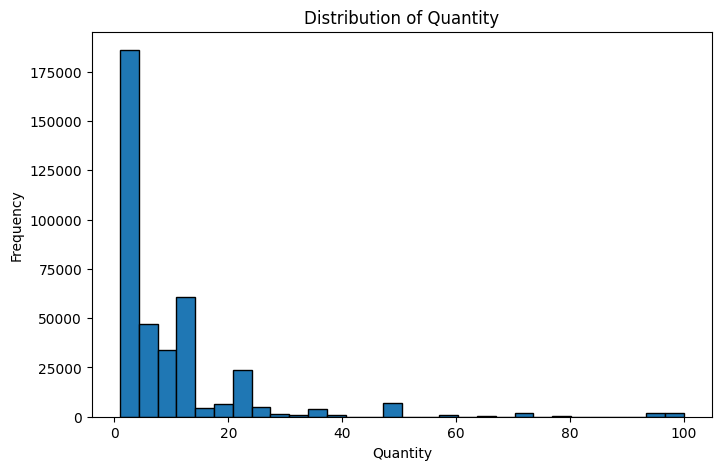

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Create a temporary dataset for visualization
quantity_plot = df[df['Quantity'] <= 100]

plt.figure(figsize=(8,5))
plt.hist(quantity_plot['Quantity'], bins=30, edgecolor='black')

plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

**Report Observation:**

The quantity distribution is highly right-skewed, with most customers purchasing small quantities (typically between 1 and 10 units). A limited number of transactions involve bulk purchases, which appear as outliers.

**Step 2(b)-2: Distribution of Unit Price**

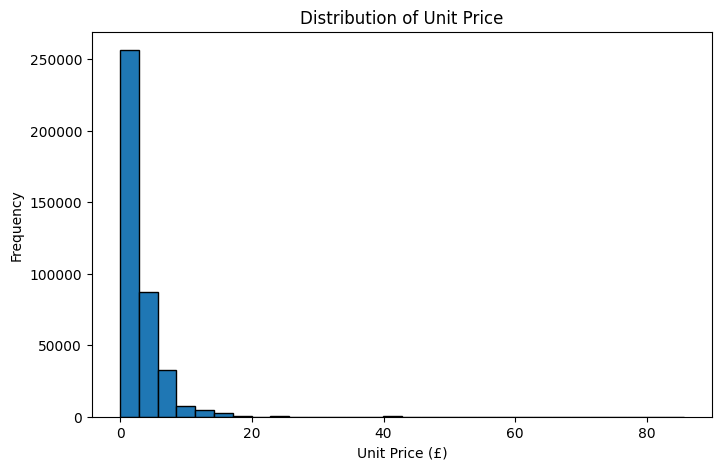

In [15]:
# Create a temporary dataset for visualization
price_plot = df[df['UnitPrice'] <= 100]

plt.figure(figsize=(8,5))
plt.hist(price_plot['UnitPrice'], bins=30, edgecolor='black')

plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price (£)')
plt.ylabel('Frequency')

plt.show()

**Report Observation:**

The unit price distribution is positively skewed, indicating that the majority of products are low-priced. Only a small proportion of products have relatively high prices, suggesting that the retailer mainly sells affordable items.

**Task 2(c): Top 10 Products by Sales**

**Step 1: Create a Sales column**

In [16]:
# Create sales column
df['Sales'] = df['Quantity'] * df['UnitPrice']

# Display first few rows
df[['Description', 'Quantity', 'UnitPrice', 'Sales']].head()

,Description,Quantity,UnitPrice,Sales
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,WHITE METAL LANTERN,6,3.39,20.34
2,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34


**Step 2: Calculate Top 10 Products by Revenue**

In [17]:
top_products = (
    df.groupby('Description')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Sales, dtype: float64


# **Step 3: Visualize the Top 10 Products**

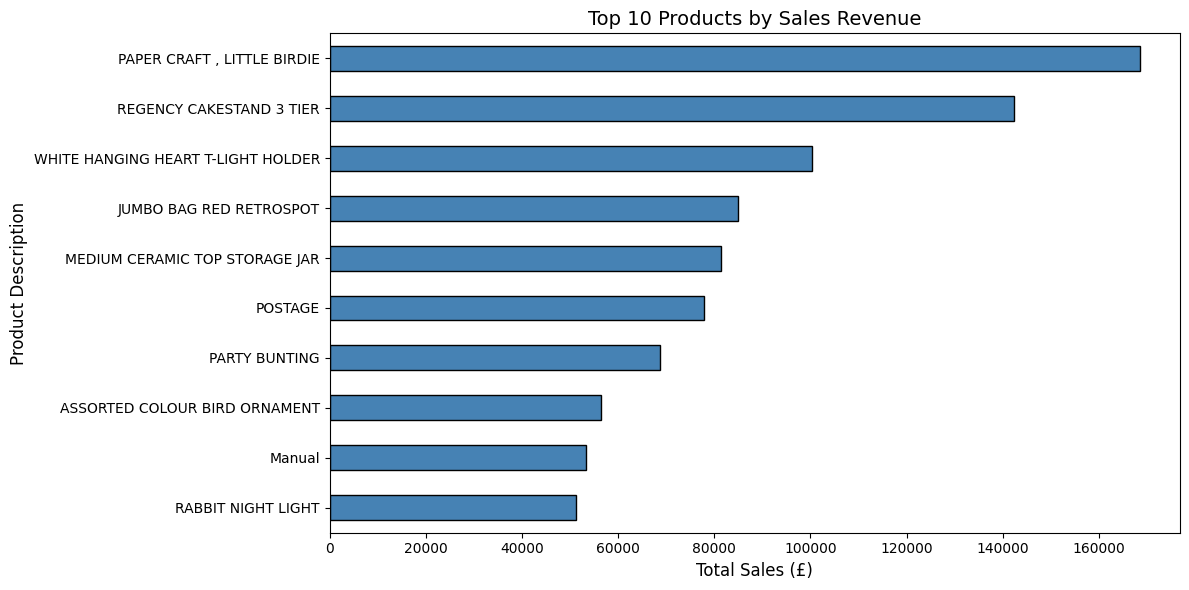

In [18]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)

plt.title('Top 10 Products by Sales Revenue', fontsize=14)
plt.xlabel('Total Sales (£)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)

plt.tight_layout()
plt.show()

**Report Observation**

The analysis shows that PAPER CRAFT, LITTLE BIRDIE generated the highest revenue, followed by REGENCY CAKESTAND 3 TIER and WHITE HANGING HEART T-LIGHT HOLDER. These products contribute significantly to total sales and should be prioritized for inventory planning, marketing campaigns, and demand forecasting.

**Task 3: Time-Series Analysis**

**Step 3(a): Create Monthly Time Series of Total Sales**

In [19]:
# Extract year-month from InvoiceDate
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Calculate monthly sales
monthly_sales = (
    df.groupby('YearMonth')['Sales']
      .sum()
)

# Convert PeriodIndex to Timestamp for plotting
monthly_sales.index = monthly_sales.index.to_timestamp()

# Display monthly sales
monthly_sales

,Sales
YearMonth,
2010-12-01,570422.730
2011-01-01,568101.310
2011-02-01,446084.920
2011-03-01,594081.760
2011-04-01,468374.331
2011-05-01,677355.150
2011-06-01,660046.050
2011-07-01,598962.901
2011-08-01,644051.040


**Step 3(b): Plot Monthly Sales**

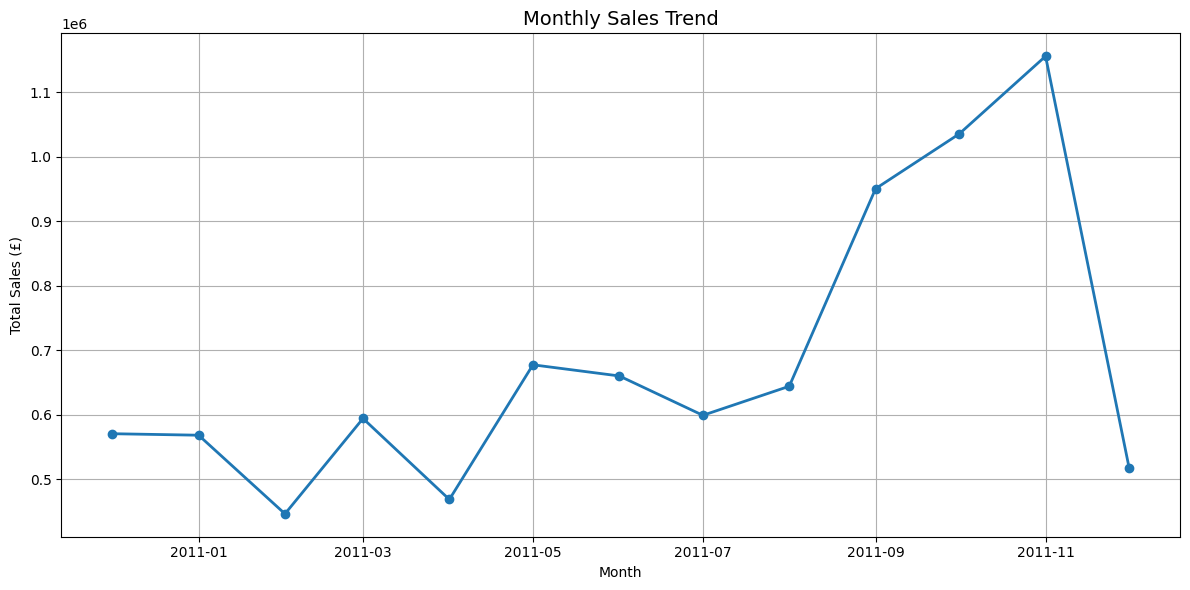

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales (£)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Step 3(c): Calculate Month-over-Month (MoM) Percentage Growth**

In [21]:
# Calculate percentage growth
mom_growth = monthly_sales.pct_change() * 100

# Display results
print(mom_growth.round(2))

YearMonth
2010-12-01      NaN
2011-01-01    -0.41
2011-02-01   -21.48
2011-03-01    33.18
2011-04-01   -21.16
2011-05-01    44.62
2011-06-01    -2.56
2011-07-01    -9.25
2011-08-01     7.53
2011-09-01    47.61
2011-10-01     8.94
2011-11-01    11.64
2011-12-01   -55.27
Freq: MS, Name: Sales, dtype: float64


**Plot Month-over-Month Growth**

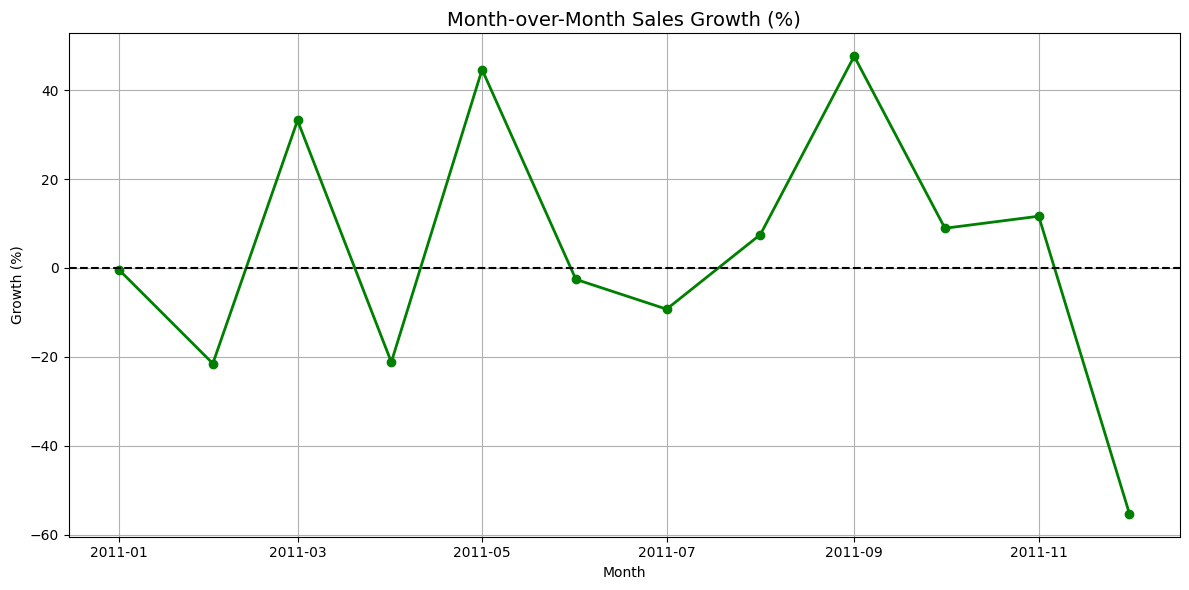

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    mom_growth.index,
    mom_growth.values,
    marker='o',
    color='green',
    linewidth=2
)

plt.axhline(0, color='black', linestyle='--')

plt.title('Month-over-Month Sales Growth (%)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Growth (%)')

plt.grid(True)

plt.tight_layout()
plt.show()

# **Task 4: Customer Behavior**

**Step 4(a): Calculate Total Sales per Customer**

In [23]:
# Total sales for each customer
customer_sales = (
    df.groupby('CustomerID')['Sales']
      .sum()
      .sort_values(ascending=False)
)

customer_sales.head(10)

,Sales
CustomerID,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


**Step 4(b): Segment Customers**

We'll use quantile-based segmentation, which is widely accepted because it divides customers into three balanced groups.

Segmentation Logic
*  Low Spenders: Bottom 33% of customers
*  Medium Spenders: Middle 33%
*  High Spenders: Top 33%

In [24]:
# Create customer segments
customer_segments = pd.qcut(
    customer_sales,
    q=3,
    labels=['Low', 'Medium', 'High']
)

customer_df = pd.DataFrame({
    'TotalSales': customer_sales,
    'Segment': customer_segments
})

customer_df.head()

,TotalSales,Segment
CustomerID,,
14646,280206.02,High
18102,259657.30,High
17450,194390.79,High
16446,168472.50,High
14911,143711.17,High


**Step 4(c): Calculate Average Order Value (AOV)**

**Step 1: Calculate Invoice Value**

In [25]:
invoice_sales = (
    df.groupby(['CustomerID', 'InvoiceNo'])['Sales']
      .sum()
      .reset_index()
)

**Step 2: Assign Customer Segments**

In [26]:
invoice_sales = invoice_sales.merge(
    customer_df[['Segment']],
    left_on='CustomerID',
    right_index=True
)

**Step 3: Compute AOV by Segment**

In [27]:
aov = (
    invoice_sales.groupby('Segment')['Sales']
                 .mean()
                 .sort_values()
)

print(aov)

Segment
Low       165.625219
Medium    274.365638
High      585.666015
Name: Sales, dtype: float64


/tmp/ipykernel_2010/3332047545.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  invoice_sales.groupby('Segment')['Sales']


**Step 4: Visualize AOV**

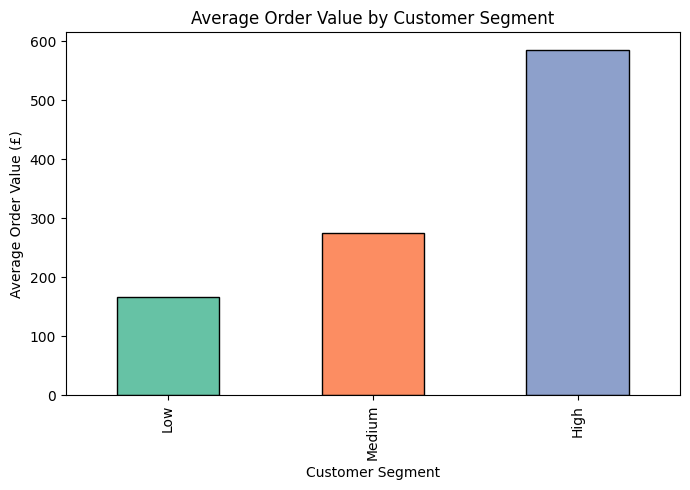

In [28]:
plt.figure(figsize=(7,5))

aov.plot(
    kind='bar',
    color=['#66c2a5', '#fc8d62', '#8da0cb'],
    edgecolor='black'
)

plt.title('Average Order Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Order Value (£)')

plt.tight_layout()
plt.show()

# **Task 5: Product Analysis**

**5(a): Identify Which Country Contributes the Most Revenue**

**Step 1: Calculate Revenue by Country**

In [29]:
# Calculate total revenue by country
country_revenue = (
    df.groupby('Country')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(country_revenue)

Country
United Kingdom          7285024.644
Netherlands              285446.340
EIRE                     265262.460
Germany                  228678.400
France                   208934.310
Australia                138453.810
Spain                     61558.560
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38367.830
Japan                     37416.370
Norway                    36165.440
Portugal                  33375.840
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20440.540
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13502.850
Austria                   10198.680
Poland                     7334.650
Israel                     7215.840
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

**Step 2: Visualize the Top 10 Countries**

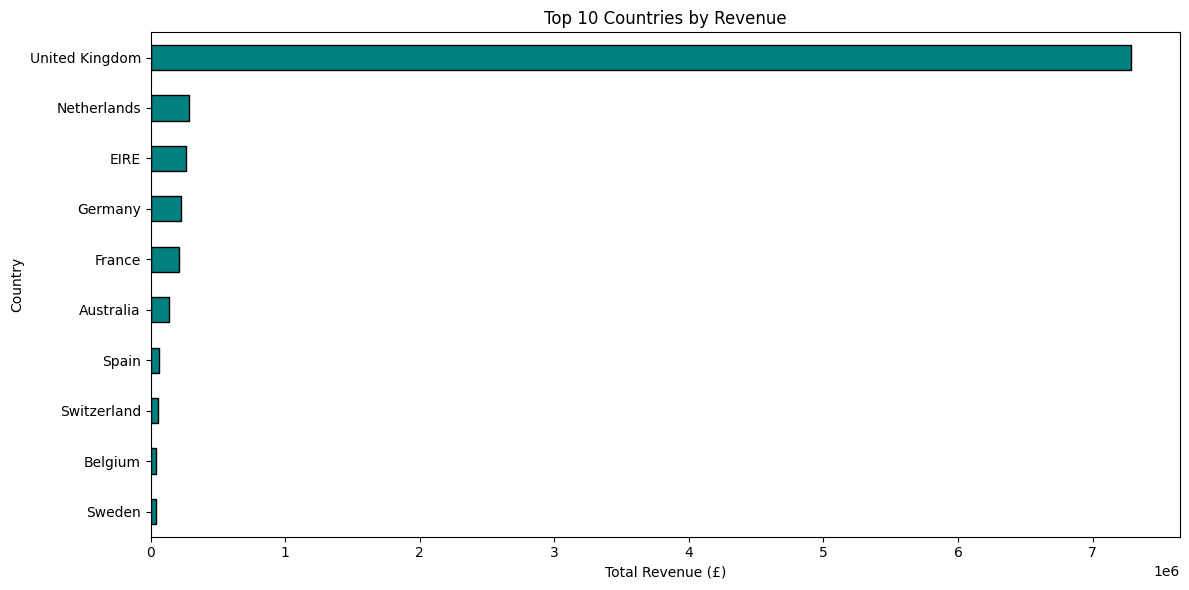

In [30]:
plt.figure(figsize=(12,6))

country_revenue.head(10).sort_values().plot(
    kind='barh',
    color='teal',
    edgecolor='black'
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

**Step 3: Find the Highest Revenue Country**

In [31]:
top_country = country_revenue.idxmax()

print("Top Revenue Country:", top_country)

Top Revenue Country: United Kingdom


**Task 5(b): Analyze Top Products in the Highest Revenue Country**

**Step 1: Filter Data**

In [32]:
top_country_df = df[df['Country'] == top_country]

**Step 2: Calculate Product Revenue**

In [33]:
top_country_products = (
    top_country_df.groupby('Description')['Sales']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
)

print(top_country_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              110713.00
WHITE HANGING HEART T-LIGHT HOLDER     94805.50
MEDIUM CERAMIC TOP STORAGE JAR         80291.44
JUMBO BAG RED RETROSPOT                77191.33
PARTY BUNTING                          63050.28
ASSORTED COLOUR BIRD ORNAMENT          52228.68
CHILLI LIGHTS                          45483.91
PAPER CHAIN KIT 50'S CHRISTMAS         40392.08
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Sales, dtype: float64


**Step 3: Plot the Top Products**

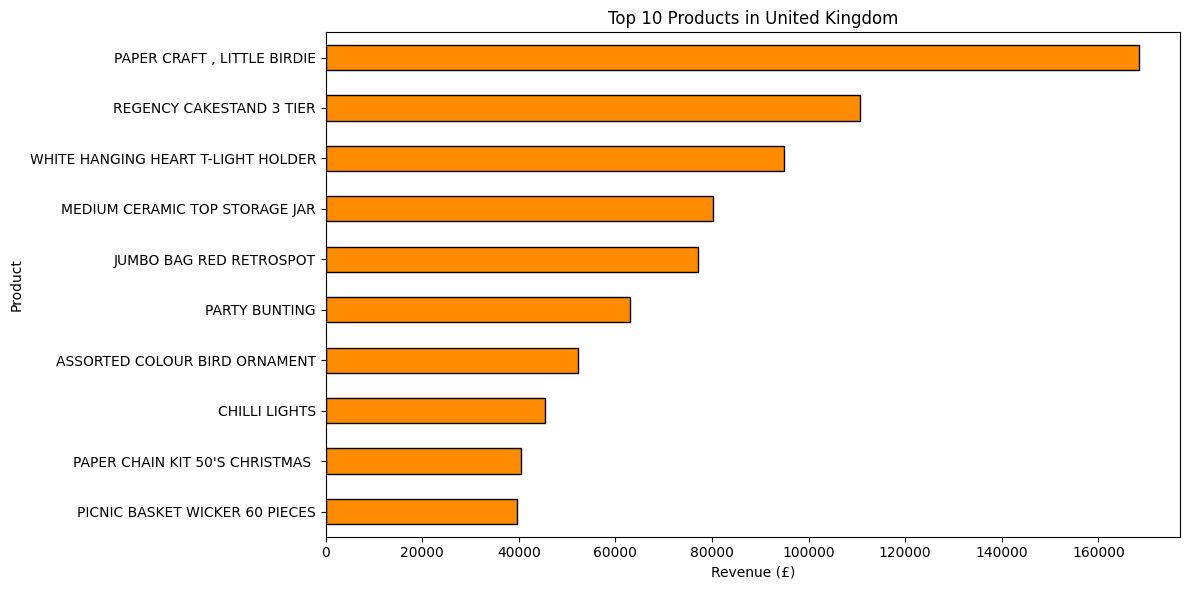

In [34]:
plt.figure(figsize=(12,6))

top_country_products.sort_values().plot(
    kind='barh',
    color='darkorange',
    edgecolor='black'
)

plt.title(f'Top 10 Products in {top_country}')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

# **# Task 6: Insights & Recommendations**

**6(a) Three Actionable Recommendations**

**Recommendation 1: Focus on High-Value Customers**

High-spending customers have an average order value of approximately £586, significantly higher than the other customer segments. The company should implement loyalty programs, exclusive discounts, and personalized marketing campaigns to retain these valuable customers and encourage repeat purchases.

**Recommendation 2: Prioritize Top-Selling Products**

Products such as PAPER CRAFT, LITTLE BIRDIE, REGENCY CAKESTAND 3 TIER, and WHITE HANGING HEART T-LIGHT HOLDER generate the highest revenue. Maintaining sufficient inventory, highlighting these products in promotional campaigns, and recommending them through cross-selling strategies can further increase sales.

**Recommendation 3: Prepare for Seasonal Demand**

Monthly sales increase substantially between September and November, with November showing the highest revenue. The company should increase inventory, staffing, and marketing efforts before this peak season to maximize sales opportunities and improve customer satisfaction.

**6(b) Limitation of the Analysis**

This analysis is based on transactional data from a single year and does not include customer demographics, marketing campaign information, product categories, or profit margins. Access to multi-year historical data and additional customer information would allow more accurate demand forecasting, customer lifetime value analysis, and more detailed customer segmentation.